---

# **🔆​ Carga del DataSet**

In [7]:
import pandas as pd
import numpy  as np

df_insumos = pd.read_csv('/data_insumos_gastro.csv')
df_insumos.head(10)

,id_transaccion,fecha_compra,nombre_empresa_cliente,categoria_producto,producto_sku,cantidad,precio_unitario,metodo_pago,estado_pedido,descuento_aplicado
0,1,3/23/2024,Agivu,insumos gastronómicos de alta calidad,"Pasta - Spaghetti, Dry",270,$1087.33,transferencia,error: undefined method `first' for nil:NilClass,25.0
1,2,10/27/2025,Devshare,insumos gastronómicos de alta calidad,Pork - Smoked Kassler,168,$4379.50,transferencia,NaN,7.0
2,3,1/22/2026,Blogspan,insumos gastronómicos de alta calidad,Versatainer Nc - 8288,149,$4220.24,tarjeta de crétdito,error: undefined method `first' for nil:NilClass,26.0
3,4,11/23/2024,NaN,insumos gastronómicos de alta calidad,Appetizer - Mushroom Tart,497,$2520.10,tarjeta débito,error: undefined method `first' for nil:NilClass,7.0
4,5,12/2/2024,Feedspan,insumos gastronómicos de alta calidad,Nacho Chips,98,$2524.85,tarjeta de crétdito,NaN,16.0
5,6,5/18/2024,Trilia,insumos gastronómicos de alta calidad,Bread - 10 Grain,436,$4278.01,Tarjeta,NaN,NaN
6,7,11/4/2024,Zoozzy,insumos gastronómicos de alta calidad,Cheese - Grana Padano,232,$4205.72,cheque a 30 dias,error: undefined method `first' for nil:NilClass,15.0
7,8,7/1/2025,Vimbo,insumos gastronómicos de alta calidad,Calypso - Black Cherry Lemonade,413,$827.21,Efectivo,error: undefined method `first' for nil:NilClass,26.0
8,9,10/9/2024,Youspan,insumos gastronómicos de alta calidad,Flour - Masa De Harina Mexican,37,$2396.33,cheque a 30 dias,error: undefined method `first' for nil:NilClass,8.0
9,10,3/19/2025,Devpoint,insumos gastronómicos de alta calidad,"Cup - 3.5oz, Foam",196,$3129.95,Cheque,error: undefined method `first' for nil:NilClass,NaN


In [8]:
def resumen_EDA(dataframe):
  print(f"📐​ Tamaño del DataFrame")
  print("Columnas:", dataframe.shape[1])
  print(f"Filas:", dataframe.shape[0])

  print("-" * 64)

  print("📌​ Tipos de datos")
  print(dataframe.dtypes)

  print("-" * 64)

  print("🔎 Valores nulos por columna")
  print(dataframe.isnull().sum())

  print("-" * 64)

  print("🔎 Valores duplicados")
  print(dataframe.duplicated().sum())

  print("-" * 64)

  return
resumen_EDA(df_insumos)

📐​ Tamaño del DataFrame
Columnas: 10
Filas: 1000
----------------------------------------------------------------
📌​ Tipos de datos
id_transaccion              int64
fecha_compra               object
nombre_empresa_cliente     object
categoria_producto         object
producto_sku               object
cantidad                    int64
precio_unitario            object
metodo_pago                object
estado_pedido              object
descuento_aplicado        float64
dtype: object
----------------------------------------------------------------
🔎 Valores nulos por columna
id_transaccion              0
fecha_compra                0
nombre_empresa_cliente     68
categoria_producto          0
producto_sku                0
cantidad                    0
precio_unitario             0
metodo_pago                 0
estado_pedido             114
descuento_aplicado        395
dtype: int64
----------------------------------------------------------------
🔎 Valores duplicados
0
--------------------

Identifico la siguiente información e inconsistencias:

*   Hay 1000 entradas, 10 columnas
*   Hay que cambiar los tipos de datos en algunas columnas y manejar los datos nulos.

*   Analizo por columna:

**📌 Columna 0: id_transaccion**

-) no hay nulos

-) tipo int-> ok

**📌 Columna 1:  fecha_compra**

-) no hay nulos

-) tipo object -> cambiar a 'datetime'

**📌 Columna 2:  nombre_empresa_cliente**

-) hay 68 entradas null

-) tipo object -> cambiar a 'string'

**📌 Columna 3: categoria_producto**

-) no hay nulos

-) tipo object -> cambiar a 'string'

**📌 Columna 4: producto_sku**

-) no hay nulos

-) tipo object -> cambiar a 'string'

**📌 Columna 5: cantidad**

-) no hay nulos

-) tipo int -> ok

**📌 Columna 6: precio_unitario**

-) no hay nulos

-) tipo object -> cambiar a 'float'

-) eliminar signo '$'

**📌 Columna 7: metodo_pago**

-) no hay nulos

-) tipo object -> cambiar a 'string'

**📌 Columna 8: estado_pedido**

-) hay 114 datos nulos

-) tipo object -> cambiar a string

**📌 Columna 9: descuento_aplicado**

-) hay 395 nulos

-) tipo float -> cambiar a 'int'

 ---



# **🧹Limpeza y Tratamiento de Datos sobre el DataFrame de Insumos**



In [9]:
df_insumos_clean = df_insumos.copy()

### COLUMNA 1 => fecha_compra
df_insumos_clean["fecha_compra"] = pd.to_datetime(df_insumos_clean["fecha_compra"], dayfirst=True, errors="coerce", format='mixed')

### COLUMNA 2 => nombre_empresa_cliente
df_insumos_clean["nombre_empresa_cliente"] = df_insumos_clean["nombre_empresa_cliente"].fillna("Cliente No Registrado")
df_insumos_clean["nombre_empresa_cliente"] = df_insumos_clean["nombre_empresa_cliente"].astype(str)

### COLUMNA 4 => producto_sku
df_insumos_clean["producto_sku"] = df_insumos_clean["producto_sku"].astype(str)

### COLUMNA 6 => precio_unitario
df_insumos_clean["precio_unitario"] = df_insumos_clean["precio_unitario"].str.replace('$', '', regex=False)
df_insumos_clean["precio_unitario"] = df_insumos_clean["precio_unitario"].astype(float)

### COLUMNA 7 => metodo_pago
df_insumos_clean["metodo_pago"] = df_insumos_clean["metodo_pago"].astype(str)

### COLUMNA 8 => estado_pedido
df_insumos_clean["estado_pedido"] = df_insumos_clean["estado_pedido"].fillna("Desconocido")
df_insumos_clean["estado_pedido"] = df_insumos_clean["estado_pedido"].astype(str)

### COLUMNA 9 => descuento_aplicado
df_insumos_clean["descuento_aplicado"] = df_insumos_clean["descuento_aplicado"].fillna(0)
df_insumos_clean["descuento_aplicado"] = df_insumos_clean["descuento_aplicado"].astype(int)

df_insumos_clean.head(3)
#

,id_transaccion,fecha_compra,nombre_empresa_cliente,categoria_producto,producto_sku,cantidad,precio_unitario,metodo_pago,estado_pedido,descuento_aplicado
0,1,2024-03-23,Agivu,insumos gastronómicos de alta calidad,"Pasta - Spaghetti, Dry",270,1087.33,transferencia,error: undefined method `first' for nil:NilClass,25
1,2,2025-10-27,Devshare,insumos gastronómicos de alta calidad,Pork - Smoked Kassler,168,4379.50,transferencia,Desconocido,7
2,3,2026-01-22,Blogspan,insumos gastronómicos de alta calidad,Versatainer Nc - 8288,149,4220.24,tarjeta de crétdito,error: undefined method `first' for nil:NilClass,26


---



> **Normalización de Datos**


In [10]:
print(df_insumos_clean['metodo_pago'].unique())

['transferencia' 'tarjeta de crétdito' 'tarjeta débito' 'Tarjeta'
 'cheque a 30 dias' 'Efectivo' 'Cheque' 'Transferencia' 'TRANSF.']


In [11]:
mapeo_metodos_pago = {
    'Efectivo': 'Efectivo',
    'Tarjeta de crétdito': 'Tarjeta de crédito',
    'Tarjeta de débito': 'Tarjeta de débito',
    'TRANSF.':'Transferencia',
    'Transferencia':'Transferencia',
    'Cheque':'Cheque',
    'cheque a 30 dias':'Cheque'
}

df_insumos_clean['metodo_pago'] = df_insumos_clean['metodo_pago'].str.lower().str.strip()
df_insumos_clean['metodo_pago'] = df_insumos_clean['metodo_pago'].replace(mapeo_metodos_pago)

print(df_insumos_clean['metodo_pago'].unique())

['transferencia' 'tarjeta de crétdito' 'tarjeta débito' 'tarjeta' 'Cheque'
 'efectivo' 'cheque' 'transf.']


---



> **Tratamiento de columna 'estado_pedido' con error**


In [12]:
df_insumos_clean['estado_pedido'] = df_insumos_clean['estado_pedido'].fillna('No Registrado') # relleno con 'no registrado'
df_insumos_clean['estado_pedido'] = df_insumos_clean['estado_pedido'].apply(lambda x: 'Error de Sistema' if 'error:' in str(x) else x)

df_insumos_clean['estado_pedido'].value_counts()

,count
estado_pedido,
Error de Sistema,886
Desconocido,114


Como para el análisis que quiero realizar la columna 'estado_pedido' no me sirve, además de tener entradas sin un valor real, la elimino.

In [13]:
df_insumos_clean = df_insumos_clean.drop('estado_pedido', axis=1)
df_insumos_clean.head()

,id_transaccion,fecha_compra,nombre_empresa_cliente,categoria_producto,producto_sku,cantidad,precio_unitario,metodo_pago,descuento_aplicado
0,1,2024-03-23,Agivu,insumos gastronómicos de alta calidad,"Pasta - Spaghetti, Dry",270,1087.33,transferencia,25
1,2,2025-10-27,Devshare,insumos gastronómicos de alta calidad,Pork - Smoked Kassler,168,4379.50,transferencia,7
2,3,2026-01-22,Blogspan,insumos gastronómicos de alta calidad,Versatainer Nc - 8288,149,4220.24,tarjeta de crétdito,26
3,4,2024-11-23,Cliente No Registrado,insumos gastronómicos de alta calidad,Appetizer - Mushroom Tart,497,2520.10,tarjeta débito,7
4,5,2024-02-12,Feedspan,insumos gastronómicos de alta calidad,Nacho Chips,98,2524.85,tarjeta de crétdito,16


---

# **⚙️​Feature Engineering**

Quiero calcular el Ingreso Total por transacción, considerando el descuento.

In [14]:
Ingreso_Total = df_insumos_clean['precio_unitario'] * df_insumos_clean['cantidad'] * (1 - df_insumos_clean['descuento_aplicado'] / 100)

print(Ingreso_Total)

0      2.201843e+05
1      6.842531e+05
2      4.653237e+05
3      1.164815e+06
4      2.078457e+05
           ...     
995    4.695438e+05
996    1.963951e+05
997    2.992001e+05
998    1.299338e+06
999    1.057842e+04
Length: 1000, dtype: float64


In [15]:
### agrego 'ingreso_total' como nueva columna
df_insumos_clean['ingreso_total'] = Ingreso_Total
# muestro los números con 2 decimales
pd.options.display.float_format = '{:.2f}'.format
df_insumos_clean.head()

,id_transaccion,fecha_compra,nombre_empresa_cliente,categoria_producto,producto_sku,cantidad,precio_unitario,metodo_pago,descuento_aplicado,ingreso_total
0,1,2024-03-23,Agivu,insumos gastronómicos de alta calidad,"Pasta - Spaghetti, Dry",270,1087.33,transferencia,25,220184.32
1,2,2025-10-27,Devshare,insumos gastronómicos de alta calidad,Pork - Smoked Kassler,168,4379.50,transferencia,7,684253.08
2,3,2026-01-22,Blogspan,insumos gastronómicos de alta calidad,Versatainer Nc - 8288,149,4220.24,tarjeta de crétdito,26,465323.66
3,4,2024-11-23,Cliente No Registrado,insumos gastronómicos de alta calidad,Appetizer - Mushroom Tart,497,2520.10,tarjeta débito,7,1164815.42
4,5,2024-02-12,Feedspan,insumos gastronómicos de alta calidad,Nacho Chips,98,2524.85,tarjeta de crétdito,16,207845.65


---

# **🫟​EDA - Análisis Exploratorio**

> **🟡​ ¿Cuáles son las empresas/clientes que más compraron?**

In [33]:
# Defino una cartera de clientes fieles
cartera_clientes = [
    'Panificadora Focaccia Artesanal',
    'Casa de Tés San Telmo',
    'Yogurtería Central',
    'NutriAvena SA',
    'Trufas y Proteínas SRL',
    'Cafetería El Grano',
    'Dietética Integral',
    'Restaurante Las Olas',
    'Bistró del Centro',
    'Pastelería La Abuela',
    'Comedor Universitario FCEN',
    'Viandas Saludables',
    'Catering Eventos',
    'Hotel Plaza',
    'Bar de Especialidad'
]

# Asigno aleatoriamente estos clientes a todas las filas del dataset
np.random.seed(42) # uso una semilla para que los resultados no cambien si corro la celda dos veces
df_insumos_clean['nombre_empresa_cliente'] = np.random.choice(cartera_clientes, size=len(df_insumos_clean))

# Verifico que ahora sí hay compras agrupadas
print(df_insumos_clean['nombre_empresa_cliente'].value_counts().head())

nombre_empresa_cliente
Viandas Saludables                 87
Panificadora Focaccia Artesanal    83
Trufas y Proteínas SRL             76
Yogurtería Central                 75
Pastelería La Abuela               74
Name: count, dtype: int64


/tmp/ipykernel_7319/222788182.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


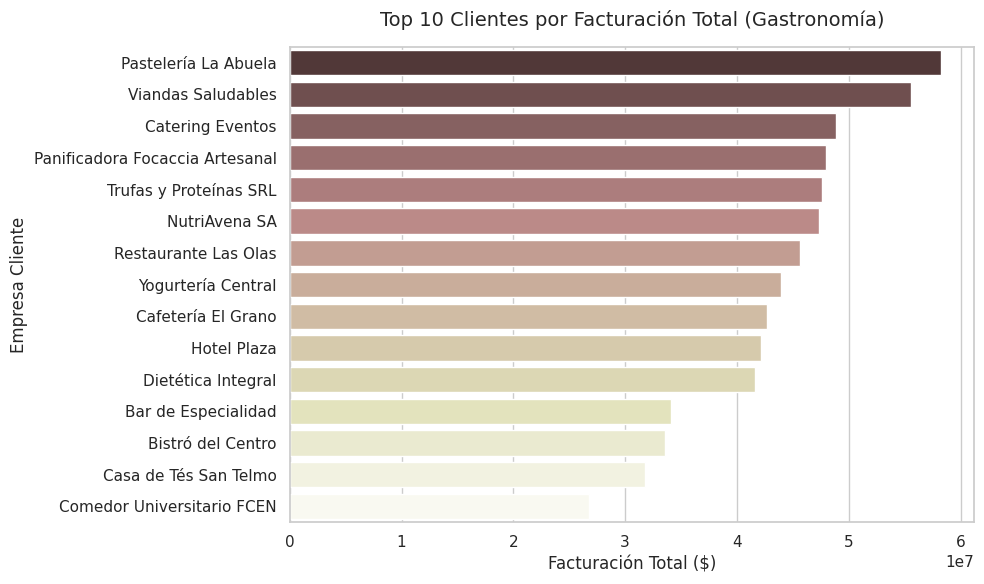

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

top_clientes = df_insumos_clean.groupby('nombre_empresa_cliente')['ingreso_total'].sum().reset_index()
top_clientes = top_clientes.sort_values(by='ingreso_total', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=top_clientes,
    x='ingreso_total',
    y='nombre_empresa_cliente',
    palette='pink'
)

plt.title('Top 10 Clientes por Facturación Total (Gastronomía)', fontsize=14, pad=15)
plt.xlabel('Facturación Total ($)', fontsize=12)
plt.ylabel('Empresa Cliente', fontsize=12)

plt.tight_layout()
plt.show()

> **🟡​ ¿Cómo es la evolución temporal de las Ventas?**

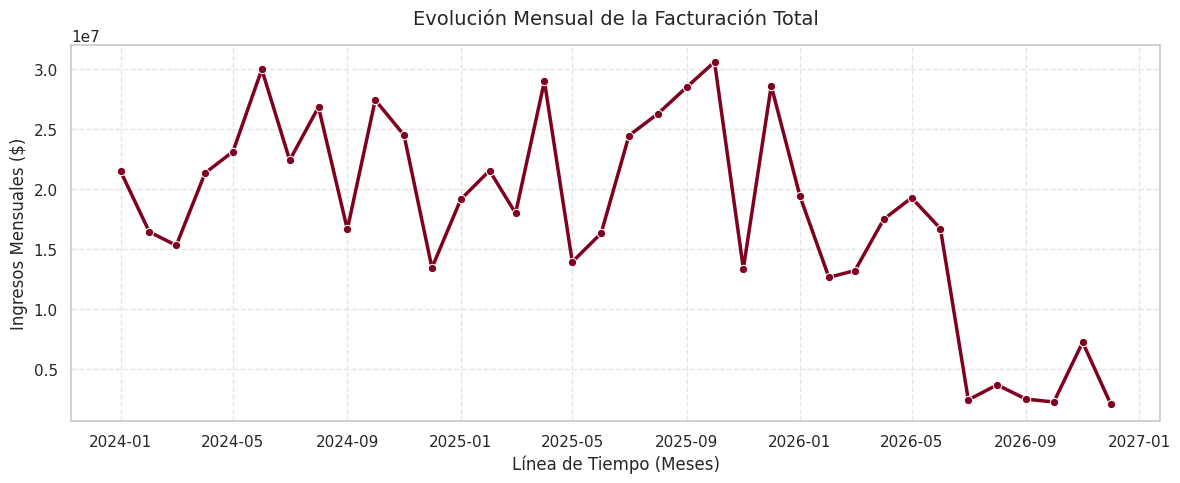

In [32]:
df_insumos_clean['año_mes'] = df_insumos_clean['fecha_compra'].dt.to_period('M')

# agrupo por el período año-mes
evolucion_ventas = df_insumos_clean.groupby('año_mes')['ingreso_total'].sum().reset_index()

# Convierto el período de nuevo a timestamp para que Matplotlib lo reconozca en el eje X
evolucion_ventas['año_mes'] = evolucion_ventas['año_mes'].dt.to_timestamp()

# grafico
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=evolucion_ventas,
    x='año_mes',
    y='ingreso_total',
    marker='o',       # Añade puntitos en cada mes
    color='#800020',  # Un azul sobrio corporativo
    linewidth=2.5
)

plt.title('Evolución Mensual de la Facturación Total', fontsize=14, pad=15)
plt.xlabel('Línea de Tiempo (Meses)', fontsize=12)
plt.ylabel('Ingresos Mensuales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Cuadrícula sutil de fondo

plt.tight_layout()
plt.show()

> **🟡​¿Cuál es la tasa de abandono? (Churn Rate)**

Para estimar la tasa de abandono ó Churn Rate, cuento con dos columnas útiles: 'fecha_compra' & 'nombre_empresa_cliente'

Si pasaron más de 60 días de la última compra -> es Churn

In [44]:
fecha_actual = df_insumos_clean['fecha_compra'].max()

# agrupo por cliente para buscar fecha de su última compra
ultimas_compras = df_insumos_clean.groupby('nombre_empresa_cliente')['fecha_compra'].max().reset_index()

# calculo los días inactivo
ultimas_compras['dias_inactivo'] = (fecha_actual - ultimas_compras['fecha_compra']).dt.days

ultimas_compras['estado_cliente'] = ultimas_compras['dias_inactivo'].apply(
    lambda x: 'Churn' if x > 60 else 'Activo'
)

# calculo la tasa de abandono
tasa_abandono = (ultimas_compras['estado_cliente'] == 'Churn').mean()

print(ultimas_compras['estado_cliente'].value_counts())

ultimas_compras.sort_values(by='dias_inactivo', ascending=False).head(20)

estado_cliente
Activo    11
Churn      4
Name: count, dtype: int64


,nombre_empresa_cliente,fecha_compra,dias_inactivo,estado_cliente
2,Cafetería El Grano,2026-06-29,158,Churn
1,Bistró del Centro,2026-08-01,125,Churn
6,Dietética Integral,2026-10-03,62,Churn
10,Pastelería La Abuela,2026-10-04,61,Churn
7,Hotel Plaza,2026-11-03,31,Activo
9,Panificadora Focaccia Artesanal,2026-11-03,31,Activo
0,Bar de Especialidad,2026-11-05,29,Activo
3,Casa de Tés San Telmo,2026-11-05,29,Activo
4,Catering Eventos,2026-11-05,29,Activo
13,Viandas Saludables,2026-11-05,29,Activo


---
# 📊​​Conclusión del Análisis 📎​

Como pudimos observar, respondimos 3 preguntas.

*  ***¿Cuáles empresas/clientes le dieron mayor ganancia a la empresa?***

Realizamos un Top 10 de clientes que han generado la mayor ganancia (se puede observar en el gráfico)

*  ***¿Cómo vinieron las ventas a lo largo del tiempo?***

Observamos que en el tramo desde Enero 2024 a Enero de 2026, las ventas se han mantenido por encima del un umbral mayor a 2.0, con pequeñas variaciones por debajo del mismo. Sin embargo, a partir de (aprox.) Febrero 2026, las ventas comenzaron a mantenerse por debajo del umbral de 2.0, incluso generando una abrupta caída por Julio de 2026.

*  ***¿Qué clientes han sido Churn? ¿Cuál fue la tasa de abandono?***

A continuación, los clientes que han tenido una tasa de abandono mayor o igual a 60 días son:

- Cafetería El Grano: con una tasa de 158 días de abandono.
- Bistró del Centro: con una tasa de 125 de abandono.
- Dietética Integral: con una tasa de 62 días de abandono.
- Pastelería La Abuela: con una tasa de 61 días de abandono.
